In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import glob

# Load data
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/VIC_clean.csv")
demand.sort()
df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")
df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = df['Datetime'].str.replace(r'\+.*$', '', regex=True)
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y-%m-%d %H:%M:%S")

# Extract features
df['Hour'] = df['Datetime'].dt.hour
df['Year'] = df['Datetime'].dt.year
df['Day'] = df['Datetime'].dt.day_name()  # Day of week
df['Month'] = df['Datetime'].dt.month

# Features
# Hour
hour_conditions = [
    (df['Hour'] >= 0) & (df['Hour'] <= 4),
    (df['Hour'] >= 5) & (df['Hour'] <= 7),
    (df['Hour'] >= 8) & (df['Hour'] <= 15),
    (df['Hour'] >= 16) & (df['Hour'] <= 18),
    (df['Hour'] >= 19) & (df['Hour'] <= 21),
    (df['Hour'] >= 22) & (df['Hour'] <= 23)
]

hour_choices = [
    (100 - ((df['Hour']) * 5)) / 100,
    (((df['Hour'] - 6) * 10) + 100) / 100,
    1.16,
    (100 + 3 + df['Hour']) / 100,
    (100 + 20 - ((df['Hour'] - 19) * 5)) / 100,
    1.02
]

df['hour_weight'] = np.select(hour_conditions, hour_choices, default=1.0)

# Day
day_conditions = [
    df["Day"].isin(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]),  # Weekdays
    df["Day"].isin(["Saturday", "Sunday"])  # Weekends
]

day_choices = [1.1, 0.9]

df['day_weight'] = np.select(day_conditions, day_choices, default=1.0)

# Month
month_conditions = [
    df["Month"].isin([4, 10, 11, 12]),  # Months 4, 10, 11, 12 -> weight 1.0
    df["Month"].isin([1, 3, 9]),       # Months 1, 3, 9 -> weight 1.04
    df["Month"].isin([2, 5]),         # Months 2, 5 -> weight 1.076
    df["Month"] == 8,                 # Month 8 -> weight 1.105
    df["Month"].isin([6, 7])          
]

month_choices = [1, 1.04, 1.076, 1.105, 1.125]

df['month_weight'] = np.select(month_conditions, month_choices, default=1.0)

# Year
year_conditions = [
    (df["Year"] >= 2000) & (df["Year"] <= 2008),
    (df["Year"] >= 2009)
]

year_choices = [1, 0.977825**(df["Year"] - 2008)]

df['year_weight'] = np.select(year_conditions, year_choices, default=1.0)

# Temperature
temp_conditions = [
    (df["Air Temp (C)"] >= 17.5) & (df["Air Temp (C)"] <= 22),
    (df["Air Temp (C)"] < 17.5),
    (df["Air Temp (C)"] > 22) 
]

temp_choices = [0.95, (112.5 - df["Air Temp (C)"])/100, (100 + (df["Air Temp (C)"] - 22) * 2)/100]

df['temp_weight'] = np.select(temp_conditions, temp_choices, default=1.0)

# Model
df['predicted_demand'] = 5000 * df['hour_weight'] * df['day_weight'] * df['month_weight'] * df['year_weight'] * df["temp_weight"]


CSV files loaded


In [3]:
# 1. Calculate Pearson correlation coefficient
correlation = df['Total Demand'].corr(df['predicted_demand'])
print(f"Pearson Correlation Coefficient: {correlation:.4f}")

# 2. Calculate accuracy (predictions within ±5% of actual)
# Compute absolute percentage error (APE)
df['absolute_error'] = abs(df['predicted_demand'] - df['Total Demand'])
df['percentage_error'] = (df['absolute_error'] / df['Total Demand']) * 100

# Check which predictions are within ±5%
df['within_5_percent'] = df['percentage_error'] <= 5

# Calculate accuracy as the proportion of predictions within ±5%
accuracy = df['within_5_percent'].mean() * 100  # Convert to percentage
print(f"Accuracy (within ±5%): {accuracy:.2f}%")

# Optional: Print a sample of the data for verification
print("\nSample of data with errors:")
print(df[['Total Demand', 'predicted_demand', 'percentage_error', 'within_5_percent']].head(10))

# Optional: Save results to CSV for further analysis
df[['Total Demand', 'predicted_demand', 'percentage_error', 'within_5_percent']].to_csv('model_evaluation_5percent.csv', index=False)
print("Results saved to 'model_evaluation_5percent.csv'")

Pearson Correlation Coefficient: 0.8343
Accuracy (within ±5%): 41.52%

Sample of data with errors:
   Total Demand  predicted_demand  percentage_error  within_5_percent
0    4599.70167          4392.648          4.501459              True
1    4478.99000          4165.668          6.995372             False
2    4228.81000          4178.304          1.194331              True
3    3989.10000          3914.352          1.873806              True
4    3783.93167          3938.220          4.077461              True
5    3631.17167          3725.280          2.591679              True
6    3518.08167          3736.512          6.208791             False
7    3467.88000          4220.424         21.700405             False
8    3393.39667          4216.212         24.247543             False
9    3376.70333          4694.040         39.012508             False
Results saved to 'model_evaluation_5percent.csv'


In [107]:
df[["Year", "Month", "Day", "Hour", "Total Demand", "Air Temp (C)"]]

,Year,Month,Day,Hour,Total Demand,Air Temp (C)
0,2000,1,Saturday,1,4599.70167,13.7
1,2000,1,Saturday,2,4478.99000,13.6
2,2000,1,Saturday,2,4228.81000,13.3
3,2000,1,Saturday,3,3989.10000,14.1
4,2000,1,Saturday,3,3783.93167,13.5
...,...,...,...,...,...,...
377676,2019,12,Tuesday,22,4129.96000,17.1
377677,2019,12,Tuesday,22,4083.66000,16.6
377678,2019,12,Tuesday,23,4104.95000,16.3
377679,2019,12,Tuesday,23,4325.88000,16.0


In [4]:
# Train-test-split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=300000)

# DecisionTreeRegressor

regressor = DecisionTreeRegressor(max_depth=3, random_state=300000)
regressor.fit(X_train, y_train)

# Predictions on testing data and MSE
y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

NameError: name 'X' is not defined

In [5]:
# Target - actual vs predicted

plt.scatter(y_test, y_pred, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Decision Tree Regression: Predicted vs Actual")
plt.show()

NameError: name 'y_test' is not defined

Train MSE: 357883.69
Test MSE: 356309.82


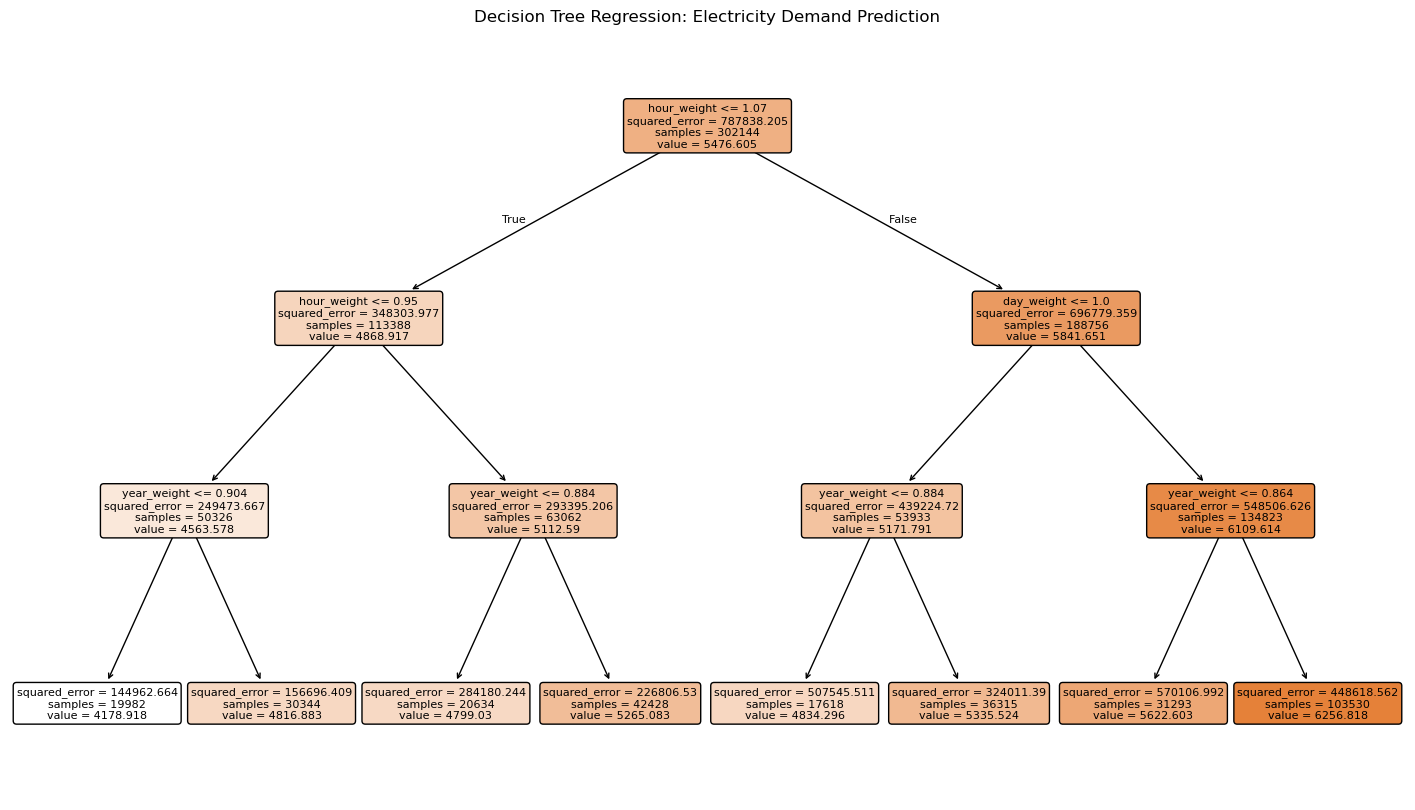

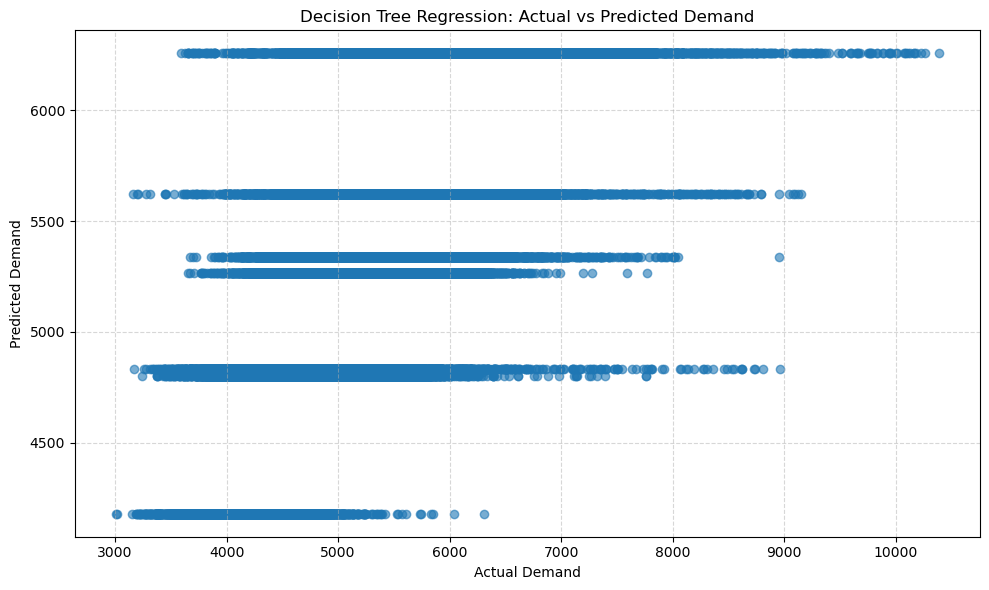

In [92]:
# --- Decision Tree Regression Model ---

# ✅ Features (X) and Target (y)
X = df[['hour_weight', 'day_weight', 'month_weight', 'year_weight']]
y = df['Total Demand']

# Split into training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Regressor
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# Make predictions
y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

# Evaluate model performance
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")

# --- Visualize Decision Tree ---
plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=['hour_weight', 'day_weight', 'month_weight', 'year_weight'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Regression: Electricity Demand Prediction")
plt.show()

# --- Compare Predicted vs Actual ---
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Decision Tree Regression: Actual vs Predicted Demand")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Number of features in X: 4
Number of importances: 4

Feature Importance:
        Feature  Importance
0   hour_weight    0.580889
1    day_weight    0.260809
3   year_weight    0.158302
2  month_weight    0.000000


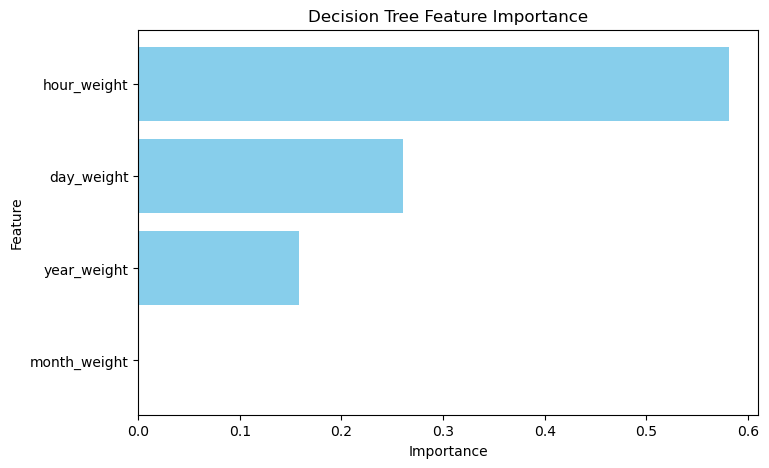

In [ ]:
# Plot feature importance
import pandas as pd
import matplotlib.pyplot as plt

# Ensure regressor is the trained DecisionTreeRegressor (named 'tree')
regressor = tree

# Get feature importances
importances = regressor.feature_importances_

# Verify lengths match to prevent ValueError
print(f"Number of features in X: {len(X.columns)}") 
print(f"Number of importances: {len(importances)}")

# Check if lengths match before creating DataFrame
if len(X.columns) == len(importances):  # Change 4: Added conditional to avoid ValueError
    feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
    feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
    print("\nFeature Importance:")
    print(feature_importance)

    plt.figure(figsize=(8, 5))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title('Decision Tree Feature Importance')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Error: The number of features in X does not match the number of importances.")
    print("Features in X:", list(X.columns))
    print("Features used in training:", regressor.feature_names_in_)
    print("Please re-train the model with the current X features.")

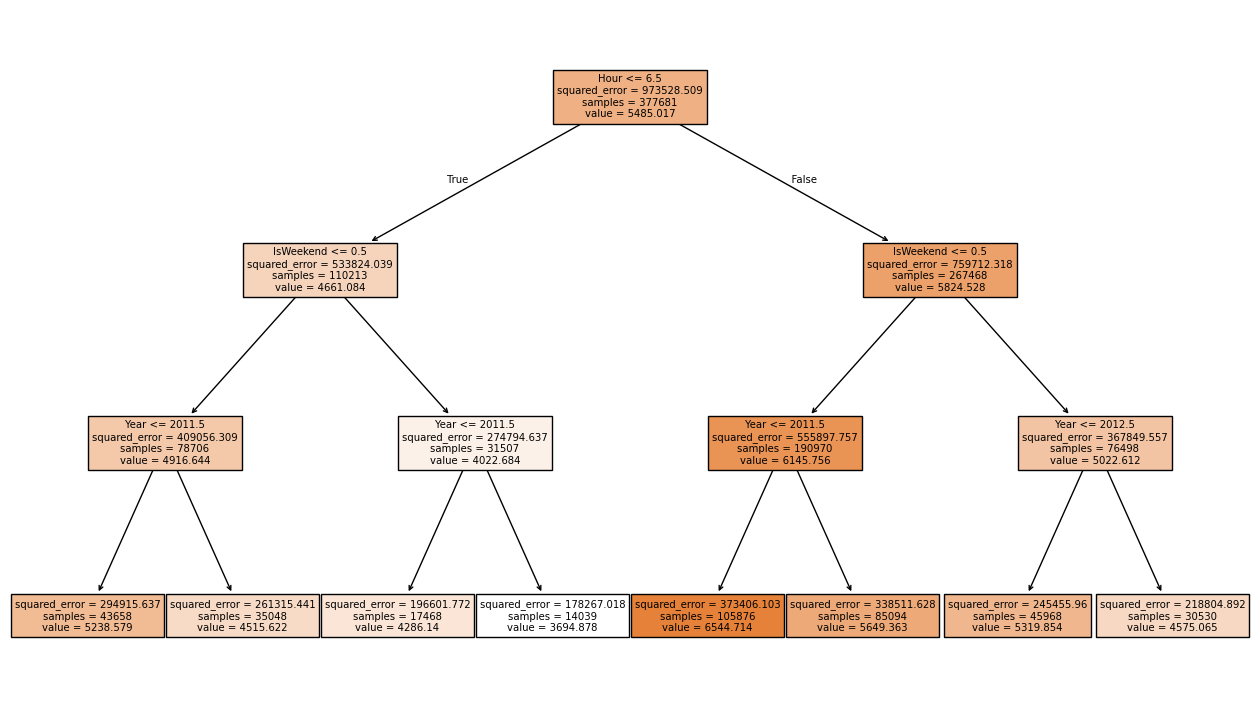

In [6]:
import numpy as np
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
import pandas as pd
import matplotlib.pyplot as plt  # Required for plotting

# Assuming df is a pandas DataFrame with the required columns

# Convert Year to integer (removing any decimal if present)
df['Year'] = df['Year'].astype(int)

# Create is_weekend column (True for Saturday/Sunday, False otherwise)
df['IsWeekend'] = df["Day"].isin(["Saturday", "Sunday"])

# Train the DecisionTreeRegressor with updated features including is_weekend
dtree = DecisionTreeRegressor(max_depth=3, min_samples_split=2)
dtree = dtree.fit(df[["Year", "Month", "Hour", "IsWeekend"]], df["predicted_demand"])

# Define feature names for plotting
labels = ["Year", "Month", "Hour", "IsWeekend"]

# Plot the decision tree
fig = plt.figure(figsize=(16, 9))  # Increased size for better visibility
tree.plot_tree(dtree, feature_names=labels, filled=True)
plt.show()